# 02 — Preprocessing

Load raw JSON, extract snapshot date from filename, cast date columns, normalise plural/singular schema splits, write clean Parquet.

## 1. Start Spark session

In [1]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName('FB_API') \
    .getOrCreate()

print('Master:', spark.sparkContext.master)
print('Spark version:', spark.version)

Master: yarn
Spark version: 3.5.0


26/04/24 03:42:35 WARN SparkSession: Using an existing Spark session; only runtime SQL configurations will take effect.


## 2. Load JSON and extract snapshot date from filename

In [2]:
from pyspark.sql.functions import input_file_name, regexp_extract, to_date, substring

DATA_PATH = '/data/ProjectDatasetFacebookAU/'

df = spark.read.json(DATA_PATH)
df = df.withColumn('filename', input_file_name())
df = df.withColumn(
    'snapshot_date',
    to_date(regexp_extract('filename', r'(\d{8})', 1), 'yyyyMMdd')
)

## 3. Cast date columns

`ad_creation_time` has two formats across the dataset: `yyyy-MM-dd` (most records) and `yyyy-MM-ddTHH:mm:ss+0000` (early records). Slicing the first 10 characters handles both safely.

Same treatment applied to `ad_delivery_start_time` and `ad_delivery_stop_time`.

In [3]:
date_cols = ['ad_creation_time', 'ad_delivery_start_time', 'ad_delivery_stop_time']

for c in date_cols:
    df = df.withColumn(
        c.replace('_time', '_date'),
        to_date(substring(c, 1, 10), 'yyyy-MM-dd')
    )

## 4. Normalise schema

The API renamed several fields from singular strings to arrays in mid-2022 (Graph API v13.0). Use `coalesce` to merge each pair into a single array column. Also drop `filename` and the original split columns — the SQL SELECT defines the final schema explicitly.

In [4]:
df.createOrReplaceTempView("ads")

df = spark.sql("""
    SELECT
        id,
        page_id,
        page_name,
        ad_creation_time,
        ad_creation_date,
        snapshot_date,
        ad_delivery_start_time,
        ad_delivery_stop_time,
        coalesce(ad_creative_bodies,            array(ad_creative_body))             AS creative_bodies,
        coalesce(ad_creative_link_captions,     array(ad_creative_link_caption))     AS creative_link_captions,
        coalesce(ad_creative_link_descriptions, array(ad_creative_link_description)) AS creative_link_descs,
        coalesce(ad_creative_link_titles,       array(ad_creative_link_title))       AS creative_link_titles,
        impressions,
        spend,
        currency,
        languages,
        publisher_platforms,
        demographic_distribution,
        estimated_audience_size,
        ad_snapshot_url,
        coalesce(bylines, funding_entity)                  AS bylines,
        coalesce(delivery_by_region, region_distribution)  AS delivery_by_region
    FROM ads
""")

df.printSchema()

root
 |-- id: string (nullable = true)
 |-- page_id: string (nullable = true)
 |-- page_name: string (nullable = true)
 |-- ad_creation_time: string (nullable = true)
 |-- ad_creation_date: date (nullable = true)
 |-- snapshot_date: date (nullable = true)
 |-- ad_delivery_start_time: string (nullable = true)
 |-- ad_delivery_stop_time: string (nullable = true)
 |-- creative_bodies: array (nullable = false)
 |    |-- element: string (containsNull = true)
 |-- creative_link_captions: array (nullable = false)
 |    |-- element: string (containsNull = true)
 |-- creative_link_descs: array (nullable = false)
 |    |-- element: string (containsNull = true)
 |-- creative_link_titles: array (nullable = false)
 |    |-- element: string (containsNull = true)
 |-- impressions: struct (nullable = true)
 |    |-- lower_bound: string (nullable = true)
 |    |-- upper_bound: string (nullable = true)
 |-- spend: struct (nullable = true)
 |    |-- lower_bound: string (nullable = true)
 |    |-- upper_b

26/04/24 03:43:48 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


lets talk about deduping.

we have the same ad id in multiple snapshots. values like spend and impressions are cumulative totals. this might be useful later - we dont want to just keep the last ad. for now lets make a new column that labels the ad. 

In [5]:
from pyspark.sql.window import Window
from pyspark.sql.functions import row_number, col

w = Window.partitionBy("id").orderBy(col("snapshot_date").desc())
df = df.withColumn("ad_seq_no", row_number().over(w))
print("Total rows:", df.count())
print("Latest snapshot per ad:", df.filter("ad_seq_no = 1").count())

Total rows: 39584139


Latest snapshot per ad: 11852904


ok lets do some ad classification. we want to identify
a) non-political ads, so we can remove them
b) subscription political ads - join here to get more information!
c) donation farming political ads - give us your money so we can sell you more ads!
d) influencing political ads - this is what you should think!

the worry of course is ads change - can we always rely on the first or last ad? i think we can assume that if the last ad is politial, all ads are polical, and vice versa. so lets just jump in and try and classify ad_seq_no = 1

the next question - should we try and classify by fudning entity/bylines? by parsing links or by page name? by text classification? lets look at byline first

In [7]:
df.filter("ad_seq_no = 1") \
  .groupBy("bylines") \
  .count() \
  .orderBy("count", ascending=False) \
  .show(50, truncate=False)

+----------------------------------------------------+--------+
|bylines                                             |count   |
+----------------------------------------------------+--------+
|NULL                                                |11423216|
|Greenpeace Australia Pacific                        |20745   |
|Access                                              |11052   |
|Yes23                                               |9622    |
|Private Media                                       |7720    |
|Australian Labor Party                              |6324    |
|Amnesty International Australia                     |6037    |
|Victorian Labor                                     |6026    |
|The Wilderness Society                              |5055    |
|Australia for UNHCR                                 |4717    |
|Solar Saver Energy                                  |4651    |
|Oxfam Australia                                     |4612    |
|Invasive Species Council               

that's a lot of nulls. lets check them...


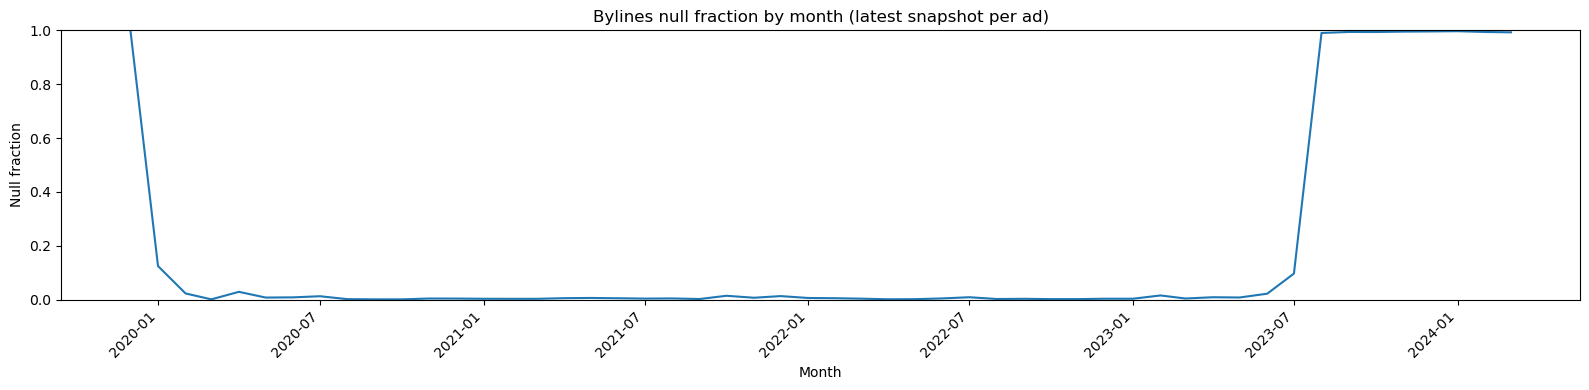

In [8]:
from pyspark.sql.functions import col, date_trunc, count, sum as spark_sum
import matplotlib.pyplot as plt
import pandas as pd

by_month = df.filter("ad_seq_no = 1") \
    .withColumn("month", date_trunc("month", "ad_creation_date")) \
    .groupBy("month") \
    .agg(
        count("*").alias("total"),
        spark_sum(col("bylines").isNull().cast("int")).alias("null_bylines")
    ) \
    .orderBy("month")

pdf = by_month.toPandas()
pdf["null_frac"] = pdf["null_bylines"] / pdf["total"]
pdf["month"] = pd.to_datetime(pdf["month"])

fig, ax = plt.subplots(figsize=(16, 4))
ax.plot(pdf["month"], pdf["null_frac"])
ax.set_title("Bylines null fraction by month (latest snapshot per ad)")
ax.set_xlabel("Month")
ax.set_ylabel("Null fraction")
ax.set_ylim(0, 1)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

ok that matches our raws. lots of nulls! i havent decided if we're going to do a hard cut-off 2023-07 yet. lets just keep poking for now. next lets look at links

In [9]:
from pyspark.sql.functions import col

# add spend midpoint as a derived column
df = df.withColumn(
    "spend_mid",
    (col("spend.lower_bound").cast("long") + col("spend.upper_bound").cast("long")) / 2
)

# top 20 ads by spend
df.filter("ad_seq_no = 1 AND spend_mid IS NOT NULL") \
  .orderBy(col("spend_mid").desc()) \
  .select("id", "bylines", "spend_mid", "creative_link_captions") \
  .show(20, truncate=80)

+----------------+---------------------------------------------+---------+--------------------------------------------------------------------------------+
|              id|                                      bylines|spend_mid|                                                          creative_link_captions|
+----------------+---------------------------------------------+---------+--------------------------------------------------------------------------------+
|5499971520113344|                                         NULL| 549999.5|[play.google.com, play.google.com, play.google.com, play.google.com, play.goo...|
|3174542729432870|                                        Shell| 424999.5|                                                              [www.shell.com.au]|
| 657206255391378|                                         NULL| 374999.5|                                                              [itunes.apple.com]|
| 192984485981892|                                         NULL|

ok there's a lot of non-political domains in there. lets generate a list of high volume non-political domains - this gives us an easy win

In [14]:
from pyspark.sql.functions import explode

df.filter("ad_seq_no = 1") \
  .select(explode("creative_link_captions").alias("domain")) \
  .groupBy("domain") \
  .count() \
  .orderBy("count", ascending=False) \
  .show(50, truncate=False)

+-----------------------------+------+
|domain                       |count |
+-----------------------------+------+
|instagram.com                |959158|
|play.google.com              |854244|
|NULL                         |585513|
|itunes.apple.com             |374777|
|m.shopcider.com              |185293|
|fb.com                       |116311|
|fb.me                        |105043|
|za.investing.com             |89126 |
|hypeddit.com                 |81067 |
|www.novel-oasis.com          |78977 |
|lightinthebox.com            |73529 |
|facebook.com                 |68589 |
|bit.ly                       |68101 |
|oxknit.com                   |67209 |
|realestate.com.au            |63146 |
|appnebula.co                 |60844 |
|youtube.com                  |60197 |
|familyshirt.store            |55345 |
|omo-app.io                   |45175 |
|aelfriceden.com              |43263 |
|Kickstarter.com              |42362 |
|mfamilyshirt.store           |40859 |
|Kickstarter.com/Just-Lau

In [11]:
commercial_domains = {
    # app stores
    "play.google.com",
    "itunes.apple.com",
    "apps.apple.com",
    
    # fitness / diet / wellness apps
    "unimeal.com",
    "betterme-pilates.com",
    "madmuscles.com",
    "yoga-go.io",
    "omo-app.io",
    "appnebula.co",
    
    # reading / entertainment / language apps
    "www.novel-oasis.com",
    "www.yumread.com",
    "hypeddit.com",
    "english-improve.com",
    "bravoshorts.com"
    
    # clothing / fashion / accessories retail
    "m.shopcider.com",
    "lightinthebox.com",
    "oxknit.com",
    "aelfriceden.com",
    "familyshirt.store",
    "mfamilyshirt.store",
    "myfamilyshirt.store",
    "myteez.store",
    "funnyfuzzy.com",
    "soodress.com",
    "curvy-faja.com",
    "soolinen.com",
    "storeluxurious.com",
    "rosewe.com",
    "mooslover.com",
    "burga.com",
    "jardinvue.com",
    "rootsinked.com",
    "shopgifnest.com",
    "makezbrightgifts.com",
    "nevstudio.com",
    
    # finance / real estate / misc commercial
    "za.investing.com",
    "realestate.com.au",
    
    # crowdfunding (mostly commercial products)
    "kickstarter.com",
    "kickstarter.com/just-launched",
}

In [12]:
from pyspark.sql.functions import lower, transform, array_intersect, array, lit, size

commercial_domains_lit = array(*[lit(d) for d in commercial_domains])

df = df.withColumn(
    "is_commercial_domain",
    size(array_intersect(
        transform("creative_link_captions", lambda x: lower(x)),
        commercial_domains_lit
    )) > 0
)

In [15]:
df.filter("ad_seq_no = 1 AND NOT is_commercial_domain") \
  .select(explode("creative_link_captions").alias("domain")) \
  .groupBy("domain") \
  .count() \
  .orderBy("count", ascending=False) \
  .show(50, truncate=False)

+------------------------+------+
|domain                  |count |
+------------------------+------+
|instagram.com           |959158|
|NULL                    |585513|
|m.shopcider.com         |185293|
|fb.com                  |116311|
|fb.me                   |105043|
|facebook.com            |68589 |
|bit.ly                  |68101 |
|youtube.com             |60197 |
|www.instagram.com       |33934 |
|bravoshorts.com         |32446 |
|en.culturess.com        |26695 |
|en.showsnob.com         |23963 |
|en.hoopshabit.com       |21093 |
|en.kckingdom.com        |19626 |
|helloice.com            |19566 |
|headway-product.com     |19438 |
|open.spotify.com        |19386 |
|www.forecastg.com       |18867 |
|cherrykitten.com        |18676 |
|api.whatsapp.com        |17737 |
|page.joyreadings.com    |17429 |
|retro-stage.com         |17415 |
|MADJOLLY.CO             |17100 |
|digitalophy.com         |16951 |
|makesyoufluent.com      |16948 |
|mx.investing.com        |16030 |
|sayabling.com

the worry with domains is extreme political ads may point to temporary or pop up domains.. we wont actually know from. lets see if we can do some text classification.

In [16]:
from pyspark.sql.functions import element_at, lower, coalesce, lit
from pyspark.ml.feature import RegexTokenizer, StopWordsRemover

# 1. extract first body, lowercase, handle nulls
df = df.withColumn(
    "body_text",
    coalesce(lower(element_at("creative_bodies", 1)), lit(""))
)

# 2. tokenise on non-word characters (splits on whitespace AND punctuation)
tokenizer = RegexTokenizer(
    inputCol="body_text",
    outputCol="tokens_raw",
    pattern=r"\W+",
    toLowercase=False  # already lowercased above
)
df = tokenizer.transform(df)

# 3. remove stop words (default English list)
remover = StopWordsRemover(inputCol="tokens_raw", outputCol="tokens")
df = remover.transform(df)

# check the result
df.filter("ad_seq_no = 1").select("body_text", "tokens").show(5, truncate=80)

+--------------------------------------------------------------------------------+--------------------------------------------------------------------------------+
|                                                                       body_text|                                                                          tokens|
+--------------------------------------------------------------------------------+--------------------------------------------------------------------------------+
|                                                     new music for indie fans...|                                                       [new, music, indie, fans]|
|perfect gift ❤ https://pfgtee.com/cruz-13k1-61-01\n collection: http://pfgtee...|[perfect, gift, https, pfgtee, com, cruz, 13k1, 61, 01, collection, http, pfg...|
|this is for the woman who’s tired of letting the aches and pains of getting o...|[woman, tired, letting, aches, pains, getting, older, prevent, fully, enjoyin...|
|wireless vacuum

lets look at the top non-stop words - maybe we can use them to build a lexicon

In [17]:
from pyspark.sql.functions import explode

df.filter("""ad_seq_no = 1 AND bylines IS NOT NULL AND NOT is_commercial_domain""") \
  .select(explode("tokens").alias("token")) \
  .filter("length(token) > 2") \
  .groupBy("token") \
  .count() \
  .orderBy("count", ascending=False) \
  .show(100, truncate=False)

+-----------+-----+
|token      |count|
+-----------+-----+
|government |84119|
|help       |81258|
|australia  |78890|
|community  |75160|
|support    |71015|
|people     |66281|
|vote       |60345|
|today      |59252|
|local      |58547|
|need       |55880|
|make       |53741|
|labor      |53451|
|like       |50801|
|new        |49864|
|climate    |48630|
|time       |47829|
|get        |47184|
|https      |42181|
|australian |40591|
|sign       |40161|
|www        |37410|
|year       |36684|
|one        |36576|
|health     |35482|
|future     |35417|
|change     |35338|
|years      |35315|
|better     |35045|
|work       |34471|
|com        |33318|
|council    |33120|
|energy     |32244|
|join       |31896|
|voice      |31887|
|take       |31628|
|world      |31247|
|children   |30454|
|nsw        |30096|
|life       |28717|
|election   |28659|
|free       |28547|
|every      |27967|
|know       |27110|
|protect    |27036|
|stop       |26999|
|want       |26905|
|state      |26759|


In [18]:
lexicons = {
    # CTAs - what the ad wants you to do
    "donation":     ["donate", "give", "fund", "contribute", "chip"],
    "subscription": ["sign", "join", "subscribe", "petition", "newsletter", "member"],
    "mobilisation": ["vote", "act", "action", "stop", "protect", "fight", "take", "support"],

    # Issue categories
    "climate":      ["climate", "energy", "gas", "environment", "future", "crisis", "planet", "power"],
    "economy":      ["cost", "living", "jobs", "business", "work", "working", "plan", "million", "tax"],
    "health":       ["health", "care", "medicare", "services"],
    "social":       ["women", "children", "families", "community", "communities"],
    "voice":        ["voice", "indigenous", "yes", "yes23", "recognition"],
    "housing":      ["home", "housing", "rent", "rental", "homes"],
    "education":    ["education", "school", "schools", "students", "university"],

    # Political identity
    "party_left":   ["labor", "greens", "alp"],
    "party_right":  ["liberal", "national", "lnp", "coalition"],
    "leaders": ["morrison", "albanese", "dutton", "shorten", "bandt", "hanson", "palmer"],
    "government":   ["government", "parliament", "federal", "council", "minister", "party", "public"],

    # Geographic/scope
    "australia":    ["australia", "australian", "australians", "nsw", "victoria", "queensland"],
}

In [19]:
from pyspark.sql.functions import explode

# flatten all lexicon words into one set
lexicon_words = {w for words in lexicons.values() for w in words}

df.filter("""ad_seq_no = 1 AND bylines IS NOT NULL AND NOT is_commercial_domain""") \
  .select(explode("tokens").alias("token")) \
  .filter("length(token) > 2") \
  .filter(~col("token").isin(list(lexicon_words))) \
  .groupBy("token") \
  .count() \
  .orderBy("count", ascending=False) \
  .show(100, truncate=False)

+-----------+-----+
|token      |count|
+-----------+-----+
|help       |81256|
|people     |66279|
|today      |59252|
|local      |58543|
|need       |55879|
|make       |53743|
|like       |50801|
|new        |49864|
|time       |47829|
|get        |47184|
|https      |42180|
|www        |37407|
|year       |36684|
|one        |36576|
|change     |35340|
|years      |35315|
|better     |35045|
|com        |33318|
|world      |31247|
|life       |28717|
|election   |28659|
|free       |28547|
|every      |27967|
|know       |27108|
|want       |26905|
|state      |26759|
|day        |26133|
|000        |25727|
|many       |24983|
|please     |24640|
|together   |23174|
|back       |21956|
|right      |21846|
|first      |21168|
|find       |20728|
|see        |20434|
|part       |19991|
|great      |19436|
|let        |19383|
|keep       |19272|
|learn      |19068|
|family     |18975|
|also       |18689|
|across     |18598|
|city       |17480|
|say        |17223|
|org        |16711|


In [21]:
df.filter("ad_seq_no = 1") \
  .groupBy("page_name") \
  .count() \
  .orderBy("count", ascending=False) \
  .show(50, truncate=False)

+-------------------------------------+-----+
|page_name                            |count|
+-------------------------------------+-----+
|realestate.com.au Promoted Properties|59304|
|Tori Repa                            |40170|
|Nebula: Zodiac Compatibility         |35789|
|Aelfric Eden                         |33304|
|12up                                 |28545|
|Mad Muscles                          |27696|
|OasisStory                           |26395|
|Cider                                |26290|
|LeNovel                              |22075|
|Headway                              |20773|
|Greenpeace Australia Pacific         |20681|
|Makezbright Gifts                    |19507|
|Promova                              |18247|
|BetterMen: Workout Planner           |18187|
|Oxknit                               |16980|
|Bellabarnett                         |16708|
|HelloIce                             |15966|
|Investing Weekly                     |15732|
|Goodteacherlife                  